In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import lxml



In [3]:
Header = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36',
          'Accept-Language': 'en-US,en;q=0.9'}

url = 'https://www.ambitionbox.com/list-of-companies?page=1'

response = requests.get(url, headers=Header).text

- There are 501 pages in total on this website & each page conatins details of 20 companies.
- I`ll be scrapping total of 10,020 companies information.



In [76]:


page = 1

while True:

    url = f"https://www.ambitionbox.com/list-of-companies?page={page}"

    response = requests.get(url, headers=Header).text

    soup = BeautifulSoup(response, "lxml")

    companies = soup.find_all(
        'div',
        class_='companyCardWrapper'
    )

    if len(companies) == 0:
        break

    # print(f"Page {page}: {len(companies)} companies")

    page += 1
    
print(page)

501


In [72]:
print(page)

1


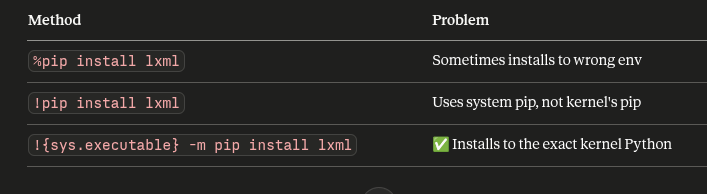

In [ ]:
import sys
!{sys.executable} -m pip install lxml


In [ ]:
soup = BeautifulSoup(response, "lxml")
soup

# It formate the data nicely

In [ ]:
print(soup.prettify())

In [ ]:
company = soup.find_all('div', class_='companyCardWrapper')
company

In [67]:

name = []
rating = []
review = []
bad_review = []
domain = []
loc = []

# Salary = []
# Interviews = []
# Jobs = []
# Benefits = []
# Photos = []
tertiaryInformations = []


for i in company:
    name.append(i.find('h2', class_ = 'companyCardWrapper__companyName').text.strip())
    rating.append(i.find('div', class_ = 'rating_star_container').text.strip())
    review.append(i.find('span', class_ = 'companyCardWrapper__companyRatingCount').text.strip()[1:-1])
    TL = i.find('span', class_ = 'companyCardWrapper__interLinking').text.strip().split('|')
    domain.append(TL[0].strip())
    loc.append(TL[1].strip())
    bad_review.append(i.find('span', class_ = 'companyCardWrapper__ratingValues').text.strip())
    
    for j in i.find_all('div', class_ = 'companyCardWrapper__tertiaryInformation'):
        tertiaryInformation = {}
        for k in j.find_all('span', class_ = 'companyCardWrapper__ActionTitle'):
            if k.text.strip() == 'Salary':
                tertiaryInformation['Salary'] = j.find('span', class_ = 'companyCardWrapper__ActionCount').text.strip()
            elif k.text.strip() == 'Interviews':
                tertiaryInformation['Interviews'] = j.find('span', class_ = 'companyCardWrapper__ActionCount').text.strip()
            elif k.text.strip() == 'Jobs':
                tertiaryInformation['Jobs'] = j.find('span', class_ = 'companyCardWrapper__ActionCount').text.strip()
            elif k.text.strip() == 'Benefits':
                tertiaryInformation['Benefits'] = j.find('span', class_ = 'companyCardWrapper__ActionCount').text.strip()
        tertiaryInformations.append(tertiaryInformation)


In [ ]:
tertiaryInformations

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'Company Name': name,
    'Rating': rating,
    'Reviews': review,
    'Bad_Review': bad_review,
    'Domain': domain,
    'Location': loc,
    'Tertiary Informations ': tertiaryInformations
})

print(df.head(2))

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

BASE_URL = "https://www.ambitionbox.com/list-of-companies?page={}"

companies_data = []

for page in range(1, 501):

    print(f"Scraping page {page}...")

    response = requests.get(
        BASE_URL.format(page),
        headers=Header,
        timeout=10
    )

    soup = BeautifulSoup(response.text, "lxml")

    company_cards = soup.find_all(
        "div",
        class_="companyCardWrapper"
    )

    if not company_cards:
        print("No more companies found.")
        break

    for card in company_cards:

        # Company basic information
        company_name = card.find(
            "h2",
            class_="companyCardWrapper__companyName"
        )

        rating = card.find(
            "div",
            class_="rating_star_container"
        )

        review_count = card.find(
            "span",
            class_="companyCardWrapper__companyRatingCount"
        )

        interlink = card.find(
            "span",
            class_="companyCardWrapper__interLinking"
        )

        bad_review = card.find(
            "span",
            class_="companyCardWrapper__ratingValues"
        )

        domain = None
        location = None

        if interlink:
            parts = interlink.text.strip().split("|")

            if len(parts) >= 2:
                domain = parts[0].strip()
                location = parts[1].strip()

        # Extract Reviews, Salaries, Interviews, Jobs...
        stats = {}

        action_wrappers = card.find_all(
            "a",
            class_="companyCardWrapper__ActionWrapper"
        )

        for action in action_wrappers:

            title = action.find(
                "span",
                class_="companyCardWrapper__ActionTitle"
            )

            count = action.find(
                "span",
                class_="companyCardWrapper__ActionCount"
            )

            if title and count:
                stats[title.text.strip()] = count.text.strip()

        companies_data.append({
            "Company Name": company_name.text.strip() if company_name else None,
            "Rating": rating.text.strip() if rating else None,
            "Reviews": review_count.text.strip()[1:-1] if review_count else None,
            "Domain": domain,
            "Location": location,
            "Bad Review": bad_review.text.strip() if bad_review else None,
            "Review Count": stats.get("Reviews"),
            "Salary Count": stats.get("Salaries"),
            "Interview Count": stats.get("Interviews"),
            "Job Count": stats.get("Jobs"),
            "Benefit Count": stats.get("Benefits"),
            "Photo Count": stats.get("Photos")
        })

df = pd.DataFrame(companies_data)

print(df.head())
print(df.shape)